# Fase 1: Análisis de Bremsstrahlung mediante Random Forest y 1D-CNN

**Presentación técnica y ejecutiva de resultados** — proyecto de espectroscopía de rayos X (EDS)

Corpus generado con EPQ + JPype · Modelos: scikit-learn (Random Forest) y PyTorch (CNN 1D) · Evidencia en `reports/` y `docs/`


## 1. Objetivo y Contexto Físico

**¿Qué es el bremsstrahlung?** (del alemán *Bremsstrahlung*, radiación de frenado)

- Es la **radiación continua de rayos X** que emiten los electrones del haz cuando se frenan en el campo de los núcleos del material blanco. Cada electrón cede una fracción distinta de su energía, por lo que el espectro resultante es un **continuo** que crece hacia bajas energías y se corta bruscamente en la energía máxima del haz.
- Ese corte es el **límite Duane–Hunt** (`h·ν_max = e·V`): con `E0 = 30 kV` no puede haber cuentas por encima de 30 keV, salvo ruido estadístico.
- **Por qué importa en EDS:** el bremsstrahlung es el **fondo continuo** sobre el que se superponen los picos característicos. Modelarlo y separarlo es un prerequisito para la cuantificación elemental, y su forma depende del material (Z), de la tensión de aceleración y de la respuesta del detector.

**Objetivo de la Fase 1**

1. Generar un **corpus reproducible** de seis espectros emitidos de bremsstrahlung puro (C, Al, Si, Cu, Ge, Au) con EPQ + JPype: `E0 = 30 kV`, 2000 trayectorias, detector SDD de 130 eV con transporte hasta el detector.
2. **Validar físicamente** el corpus antes de entrenar cualquier modelo (Duane–Hunt, ausencia de picos, linealidad, ley 1/r², dependencia con Z).
3. Clasificar los elementos a partir de la **forma del continuo** —sin usar picos característicos— comparando un **Random Forest** frente a una **CNN 1D** sobre vectores de 4096 canales normalizados L1.


**Figura 1.** Espectros de bremsstrahlung emitido (E0 = 30 kV) para los seis elementos puros del corpus.

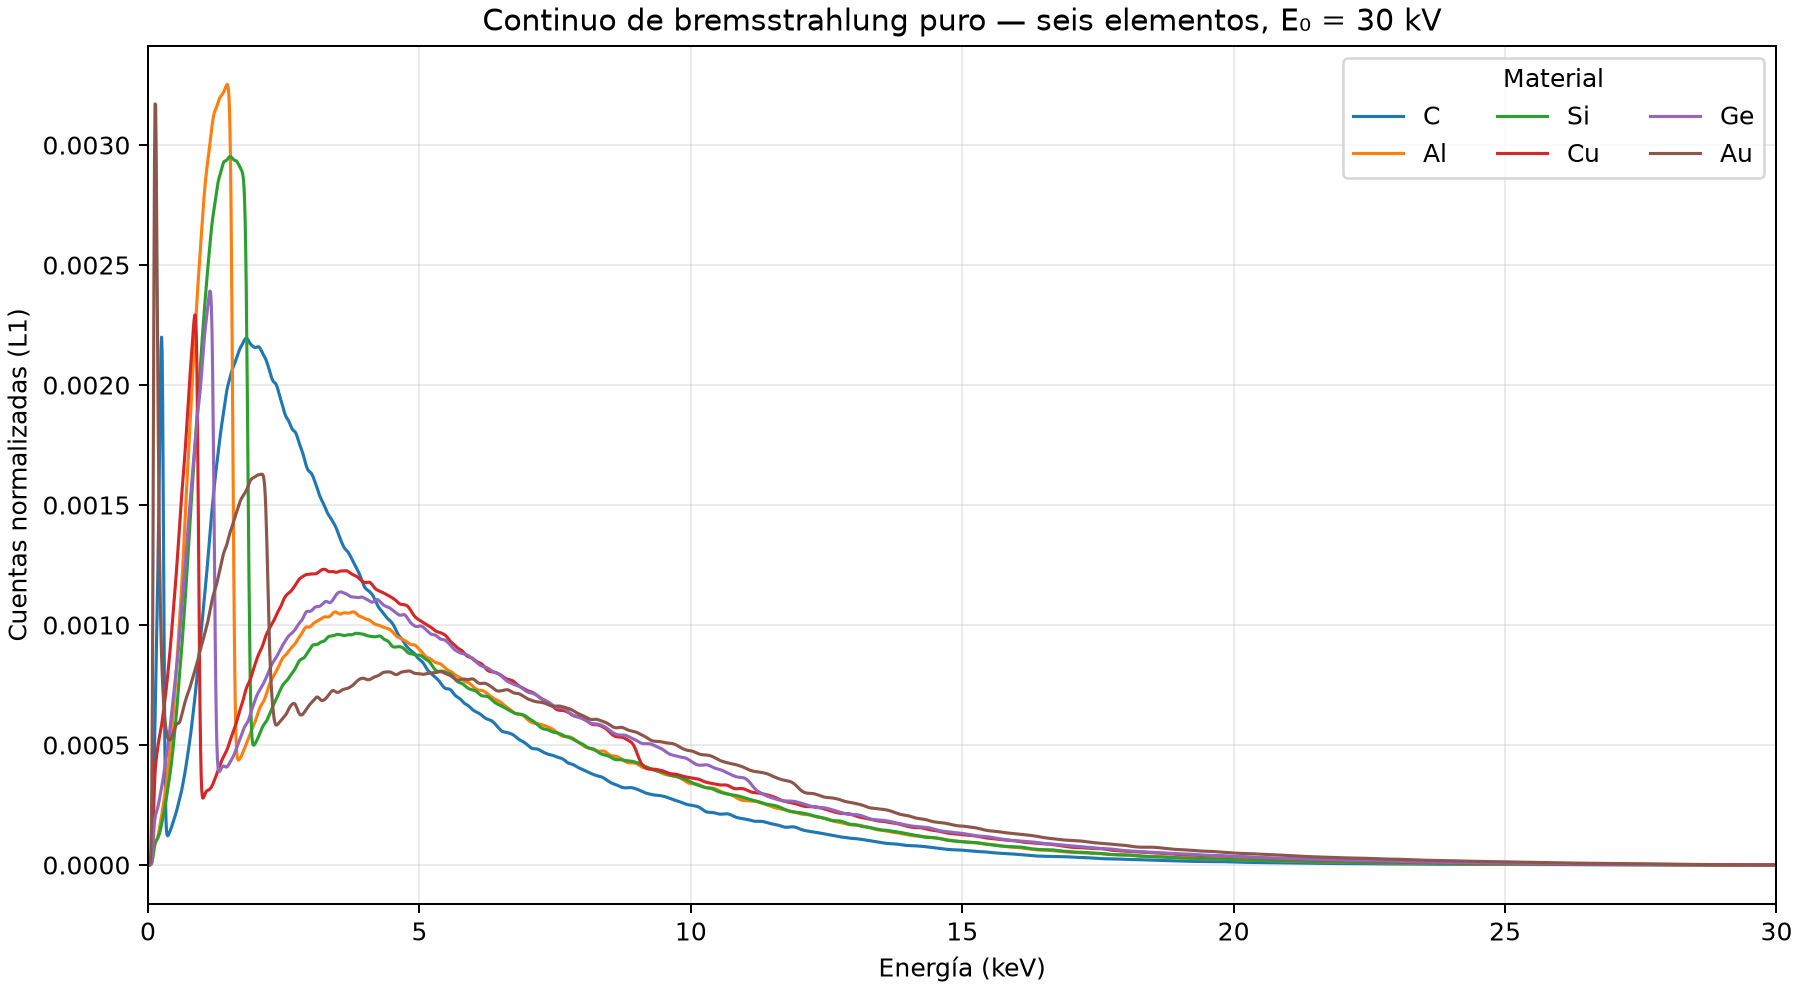

In [1]:
from IPython.display import Image, Markdown, display

display(Markdown(
    "**Figura 1.** Espectros de bremsstrahlung emitido (E0 = 30 kV) "
    "para los seis elementos puros del corpus."
))
display(Image(filename="reports/bremsstrahlung_6elementos.png", width=900))

## 2. Validación Física del Corpus

Antes de entrenar, el corpus pasó la batería de `scripts/validate_bremsstrahlung.py` (análisis de los CSV + pruebas dinámicas de simulación). **Resultado global: OK.**

| # | Chequeo | Qué comprueba | Resultado |
|:--|:--------|:--------------|:----------|
| 1 | **Corte Duane–Hunt** | Que no haya cuentas apreciables por encima de `E0 = 30 keV` (< 0.001 % del total). | ✅ **OK** — peor caso: Au con 3.1×10⁻⁵ % del total; el resto ≤ 1.4×10⁻⁵ %. |
| 2 | **Ausencia de picos característicos** | Que la única fuente instanciada sea `BremsstrahlungXRayGeneration3` y que las líneas K/L de cada elemento no presenten exceso estrecho. | ✅ **OK** — trazabilidad confirmada en `metadata.json`; ratios de línea ≈ 1.00–1.05 (Cu Kα = 1.005, Cu Kβ = 1.048, Ge Kα = 1.013, Au Lα = 1.010). |
| 3 | **Linealidad con el nº de trayectorias** (CHECK 1) | Que el total normalizado por dosis sea constante al variar `n_traj`, dentro del ruido esperado `~1/√n`. | ✅ **OK** — desviación máx. 0.7 % frente a ~1.6 % de ruido esperado. |
| 4 | **Ley 1/r² con la distancia al detector** (CHECK 2) | Que `total·r²` se mantenga constante al alejar el detector (0.05 / 0.10 / 0.15 m). | ✅ **OK** — `total·r²` = 15.5121 / 14.9971 / 15.2226 (dispersión < 4 %). |
| 5 | **Dependencia con Z** (CHECK 3) | Que la forma espectral normalizada por bandas de energía distinga los seis materiales. | ✅ **OK** — seis formas distintas por material: el continuo cambia con Z. |

> **Notas de diagnóstico**
>
> - Forma continua verificada, sin líneas estrechas: los ratios > 1.3 a baja energía (C Kα, Al Kα, Si Kα, Ge Lα) son **hombros de eficiencia/respuesta del detector**, no líneas características (diagnóstico no concluyente; ver `docs/iteraciones_fase1.md`).
> - CHECK 4 — reproducibilidad: dispersión de 2.9 % entre ejecuciones idénticas frente a ~2.2 % esperado → OK.


## 3. Resultados de Clasificación

**Configuración experimental**

| Elemento | Detalle |
|:---------|:--------|
| Clases | 6 elementos puros: C, Al, Si, Cu, Ge, Au |
| Entrada | 4096 canales normalizados L1 (la CNN escala la entrada ×4096 para estabilizar BatchNorm) |
| Corpus por nivel | 10 realizaciones Poisson por clase → **60 espectros** por dosis: low (0.1×), mid (1×), high (10×) |
| Split — Random Forest | Estratificado 80/20 → train = 48, test = 12 |
| Split — CNN 1D | Estratificado 80/10/10 → train = 48, val = 6, test = 6 |
| Entorno | CPU (PyTorch 2.14.0+cpu, scikit-learn 1.9.1), semilla 42 |

La tabla comparativa se extrae en tiempo de ejecución de `reports/fase1_resumen.md`:

In [2]:
# Extrae y muestra la tabla comparativa RF vs 1D-CNN desde reports/fase1_resumen.md
from pathlib import Path
import re

import pandas as pd
from IPython.display import display

resumen = Path("reports/fase1_resumen.md").read_text(encoding="utf-8")

# Primera tabla markdown del resumen: cabecera + filas con separador de guiones
filas_md = [l for l in resumen.splitlines() if l.strip().startswith("|")]
celdas = [[c.strip() for c in l.strip().strip("|").split("|")] for l in filas_md]


def es_separador(fila):
    return all(re.fullmatch(r":?-{3,}:?", c) for c in fila)


cabecera = celdas[0]
datos = [f for f in celdas[1:] if not es_separador(f)]

tabla = pd.DataFrame(datos, columns=cabecera)
for col in cabecera[1:]:
    tabla[col] = tabla[col].astype(float)

display(
    tabla.style
    .format({c: "{:.4f}" for c in cabecera[1:]})
    .highlight_max(subset=cabecera[1:], color="#c6efce")
    .set_caption("Accuracy en test estratificado — RF: test = 12 · CNN: test = 6")
)

,Nivel de estadística,Random Forest accuracy,CNN 1D accuracy
0,Low (0.1×),1.0000,0.6667
1,Mid (1×),1.0000,0.8333
2,High (10×),1.0000,0.6667


> ⚠️ **Advertencia — limitación actual del corpus**
>
> **Cada clase proviene de una única simulación Monte Carlo.** Las 10 muestras por clase y dosis no son simulaciones independientes: son realizaciones Poisson del mismo espectro base. Por tanto:
>
> - Un accuracy de 1.0000 mide la **separación del ruido de adquisición**, no la capacidad de **generalizar a nuevas geometrías ni a nuevas simulaciones independientes**.
> - El test es muy pequeño (12 muestras en RF, 6 en la CNN): las métricas tienen alta varianza y no permiten comparaciones finas entre modelos.
> - Los tres niveles de dosis comparten las mismas seis formas espectrales base: *low / mid / high* varía el ruido, no la señal.
>
> Estas cifras deben leerse como una **prueba de concepto de la tubería completa** (simulación → validación → preprocesado → clasificación), no como rendimiento esperado en datos nuevos. La Fase 2 existe precisamente para cerrar esta brecha.

## 4. Conclusiones y Trabajo Futuro (Fase 2)

### Conclusiones de la Fase 1

1. **Corpus reproducible y validado:** seis espectros de bremsstrahlung puro (C, Al, Si, Cu, Ge, Au) con EPQ + JPype a 30 kV / 2000 trayectorias / SDD 130 eV; los 5 chequeos físicos pasan (**Resultado global: OK**).
2. **Random Forest es el baseline operativo recomendado:** accuracy = 1.0000 y F1 macro = 1.0000 en las tres dosis, con separación perfecta en el test estratificado.
3. **La CNN 1D queda por detrás por ahora:** requirió escalar la entrada L1 ×4096 (con magnitudes ~1/4096 BatchNorm colapsaba y el modelo predecía una sola clase); alcanza 0.8333 en la dosis media y 0.6667 en low/high. Con este corpus, su complejidad adicional no se justifica todavía.
4. **Pipeline completo entregado:** corpus en `data/`, modelos en `models/` (`random_forest_bremsstrahlung.pkl`, `cnn_bremsstrahlung.pth`), métricas en `reports/` y registro de iteraciones en `docs/`.

### Plan de la Fase 2

- **Simulaciones Monte Carlo independientes por clase** (varias realizaciones MC, no una sola) y splits realizados *por simulación*, para que el test mida generalización real.
- **Variación instrumental:** resolución y eficiencia del detector, calibración en energía, deriva, ruido electrónico y distintos tiempos de adquisición.
- **Muestras compuestas y fondos reales:** mezclas de elementos, límites de detección y sustracción del bremsstrahlung.
- **Evaluación más fuerte:** validación cruzada por simulación, curvas de aprendizaje y de dosis; comparar arquitecturas de mayor capacidad (CNN 1D más profunda, transformers) solo cuando el corpus lo sustente.